In [1]:
!pip -q install geopandas shapely fiona pyproj

In [2]:
import os, zipfile, urllib.request
import geopandas as gpd

url = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2024/Brasil/BR_UF_2024.zip"
zip_path = "BR_UF_2024.zip"
out_dir = "BR_UF_2024"

# download
urllib.request.urlretrieve(url, zip_path)

# unzip
os.makedirs(out_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)

# achar o shapefile dentro da pasta
shp_file = None
for root, _, files in os.walk(out_dir):
    for f in files:
        if f.lower().endswith(".shp"):
            shp_file = os.path.join(root, f)
            break
    if shp_file:
        break

print("Shapefile:", shp_file)

# ler malha
uf = gpd.read_file(shp_file)
uf.head()


Output hidden; open in https://colab.research.google.com to view.

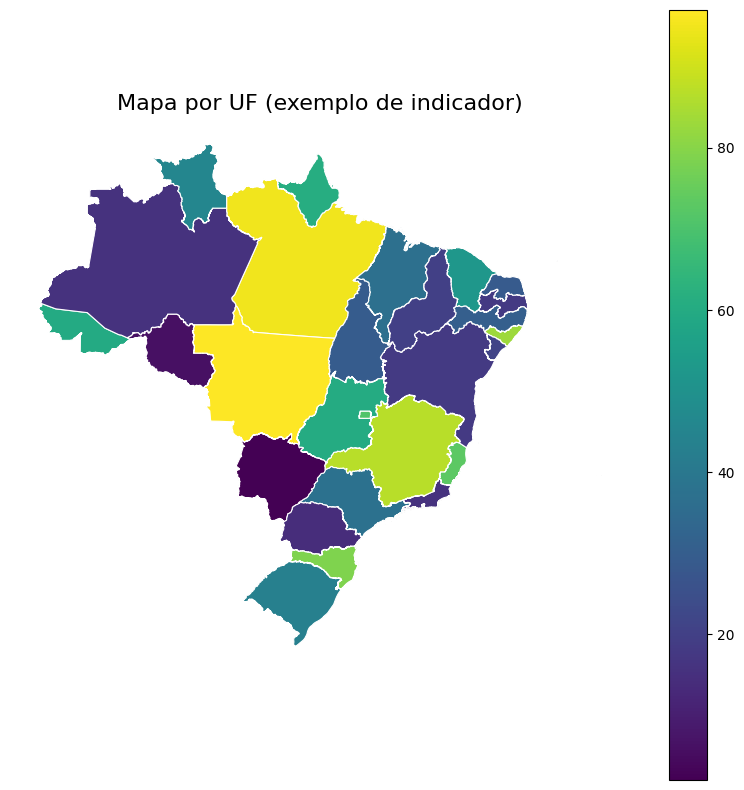

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# normalmente a coluna de sigla do estado vem como "SIGLA_UF" (pode variar)
# vamos apenas criar um valor aleatório para demonstrar
uf["indicador"] = np.random.uniform(0, 100, size=len(uf))

fig, ax = plt.subplots(figsize=(10, 10))
uf.plot(
    column="indicador",
    ax=ax,
    legend=True,
    edgecolor="white",
    linewidth=0.8
)

ax.set_title("Mapa por UF (exemplo de indicador)", fontsize=16)
ax.axis("off")
plt.show()


In [4]:
import os
import zipfile
import urllib.request
import geopandas as gpd

def baixar_e_ler_shp(url_zip, pasta_saida):
    zip_path = os.path.join(pasta_saida + ".zip")
    os.makedirs(pasta_saida, exist_ok=True)

    # download
    urllib.request.urlretrieve(url_zip, zip_path)

    # unzip
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(pasta_saida)

    # achar .shp
    shp_file = None
    for root, _, files in os.walk(pasta_saida):
        for f in files:
            if f.lower().endswith(".shp"):
                shp_file = os.path.join(root, f)
                break
        if shp_file:
            break

    if shp_file is None:
        raise FileNotFoundError("Não encontrei .shp no zip extraído.")

    return gpd.read_file(shp_file)

# URLs prováveis (IBGE). Se uma falhar, ele tenta a próxima.
urls = [
    # Brasil (microrregiões)
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_Microrregioes_2022.zip",
    # Estado específico (ex.: PE). Troque PE se quiser outro.
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/PE/PE_Microrregioes_2022.zip",
]

gdf_micro = None
ultimo_erro = None

for url in urls:
    try:
        gdf_micro = baixar_e_ler_shp(url, "malha_micro")
        print("Carregado:", url)
        break
    except Exception as e:
        ultimo_erro = e

if gdf_micro is None:
    raise RuntimeError(f"Falha ao baixar/ler as malhas. Último erro: {ultimo_erro}")

print("Colunas disponíveis:", list(gdf_micro.columns))
gdf_micro.head()


Carregado: https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_Microrregioes_2022.zip
Colunas disponíveis: ['CD_MICRO', 'NM_MICRO', 'SIGLA_UF', 'AREA_KM2', 'geometry']


,CD_MICRO,NM_MICRO,SIGLA_UF,AREA_KM2,geometry
0,11001,Porto Velho,RO,65658.650,"POLYGON ((-63.5243 -10.24964, -63.52192 -10.25..."
1,11002,Guajará-Mirim,RO,40792.646,"POLYGON ((-63.68476 -12.45306, -63.68567 -12.4..."
2,11003,Ariquemes,RO,24333.565,"POLYGON ((-62.67077 -10.28778, -62.69302 -10.3..."
3,11004,Ji-Paraná,RO,25090.399,"POLYGON ((-62.15923 -11.06775, -62.16103 -11.0..."
4,11005,Alvorada D'Oeste,RO,15965.819,"POLYGON ((-63.19546 -11.10339, -63.19459 -11.1..."


In [5]:
# tenta achar colunas comuns de código/nome
possiveis_cod = ["CD_MICRO", "CD_Micro", "CD_Microrreg", "CD_MIC", "CD_GEOCMI", "CD_GEOCMIC"]
possiveis_nome = ["NM_MICRO", "NM_Micro", "NM_Microrreg", "NM_MIC", "NM_GEOCMI", "NM_GEOCMIC"]

col_cod = next((c for c in possiveis_cod if c in gdf_micro.columns), None)
col_nome = next((c for c in possiveis_nome if c in gdf_micro.columns), None)

print("Coluna código:", col_cod)
print("Coluna nome:", col_nome)

# se não encontrar, você pode escolher manualmente olhando gdf_micro.columns


Coluna código: CD_MICRO
Coluna nome: NM_MICRO


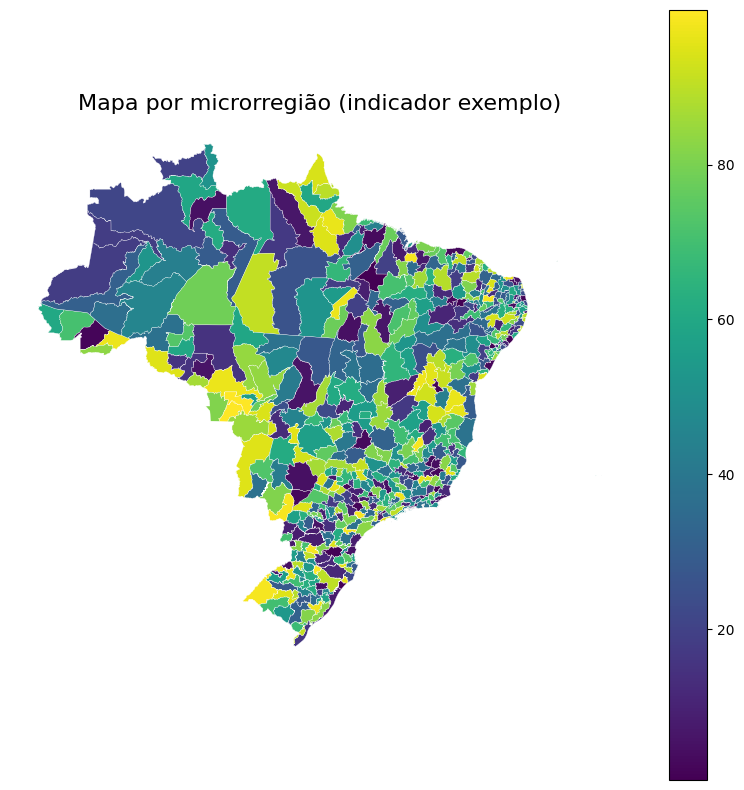

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# cria um indicador de exemplo
gdf_micro["indicador"] = np.random.uniform(0, 100, size=len(gdf_micro))

fig, ax = plt.subplots(figsize=(10, 10))
gdf_micro.plot(
    column="indicador",
    ax=ax,
    legend=True,
    edgecolor="white",
    linewidth=0.2
)

ax.set_title("Mapa por microrregião (indicador exemplo)", fontsize=16)
ax.axis("off")
plt.show()
